In [1]:
import pandas as pd 
file = "indian_ecommerce_pricing_revenue_growth_36_months.csv"
df = pd.read_csv(file)
df.shape
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30600 non-null  object 
 1   order_date             30600 non-null  object 
 2   state                  30600 non-null  object 
 3   zone                   30600 non-null  object 
 4   category               30600 non-null  object 
 5   brand_type             30600 non-null  object 
 6   customer_gender        30600 non-null  object 
 7   customer_age           30600 non-null  int64  
 8   base_price             30600 non-null  float64
 9   discount_percent       30600 non-null  float64
 10  final_price            30600 non-null  float64
 11  units_sold             30600 non-null  int64  
 12  revenue                30600 non-null  float64
 13  sales_event            30600 non-null  object 
 14  competition_intensity  30600 non-null  object 
 15  in

,order_id,order_date,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,units_sold,revenue,sales_event,competition_intensity,inventory_pressure
count,30600,30600,30600,30600,30600,30600,30600,30600.000000,30600.000000,30600.000000,30600.000000,30600.000000,30600.000000,30600,30600,30600
unique,30600,36,14,5,8,2,2,NaN,NaN,NaN,NaN,NaN,NaN,2,3,2
top,ORD0030600,2023-01-31,Maharashtra,North,Beauty & Personal Care,Mass,Male,NaN,NaN,NaN,NaN,NaN,NaN,Normal,Medium,Low
freq,1,850,2270,8772,3961,22970,15332,NaN,NaN,NaN,NaN,NaN,NaN,22889,13790,21471
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.568268,3898.637966,38.111218,2415.015197,31.705490,71062.430294,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.872780,3371.290126,16.608485,2264.892146,21.381121,83626.572222,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,100.030000,0.010000,35.010000,2.000000,247.800000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,1314.637500,24.840000,747.010000,16.000000,16689.700000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.000000,2975.015000,37.290000,1728.605000,27.000000,42138.510000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,5342.480000,51.840000,3309.630000,42.000000,92589.245000,NaN,NaN,NaN


In [3]:
# Convert order_date to datetime
from calendar import month


df ['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
# Create time features
df['order_month'] = df['order_date'].dt.to_period('M')
df['order_year'] = df['order_date'].dt.year
df['order_weekday'] = df['order_date'].dt.day_name()

# Quick sanity checks
print(df.dtypes)
df.head()

order_id                         object
order_date               datetime64[ns]
state                            object
zone                             object
category                         object
brand_type                       object
customer_gender                  object
customer_age                      int64
base_price                      float64
discount_percent                float64
final_price                     float64
units_sold                        int64
revenue                         float64
sales_event                      object
competition_intensity            object
inventory_pressure               object
order_month                   period[M]
order_year                        int32
order_weekday                    object
dtype: object


,order_id,order_date,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,units_sold,revenue,sales_event,competition_intensity,inventory_pressure,order_month,order_year,order_weekday
0,ORD0000001,2023-01-31,West Bengal,East,Fashion,Mass,Male,28,1810.89,65.00,633.81,29,18380.49,Normal,Medium,High,2023-01,2023,Tuesday
1,ORD0000002,2023-01-31,Gujarat,West,Sports & Fitness,Mass,Male,19,5678.15,50.83,2791.95,67,187060.65,Normal,Medium,High,2023-01,2023,Tuesday
2,ORD0000003,2023-01-31,Delhi NCR,North,Grocery Essentials,Mass,Male,25,169.98,35.26,110.05,57,6272.85,Normal,Medium,Low,2023-01,2023,Tuesday
3,ORD0000004,2023-01-31,Madhya Pradesh,Central,Footwear,Mass,Female,30,3244.91,61.94,1235.01,55,67925.55,Normal,High,High,2023-01,2023,Tuesday
4,ORD0000005,2023-01-31,Haryana,North,Fashion,Premium,Female,33,697.44,48.27,360.79,29,10462.91,Festival,Medium,High,2023-01,2023,Tuesday


In [7]:
total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
total_units = df['units_sold'].sum()
avg_order_value = total_revenue / total_orders

print("Total revenue:", total_revenue)
print("Total orders:", total_orders)
print("Total units sold:", total_units)
print("Average order value:", avg_order_value)

Total revenue: 2174510366.9900002
Total orders: 30600
Total units sold: 970188
Average order value: 71062.43029379085


In [5]:
monthly_rev = (
    df.groupby('order_month', as_index=False)['revenue']
      .sum()
      .sort_values('order_month')
)

monthly_rev.head()

,order_month,revenue
0,2023-01,56373285.56
1,2023-02,61494243.72
2,2023-03,59872088.97
3,2023-04,59082850.80
4,2023-05,58915576.73


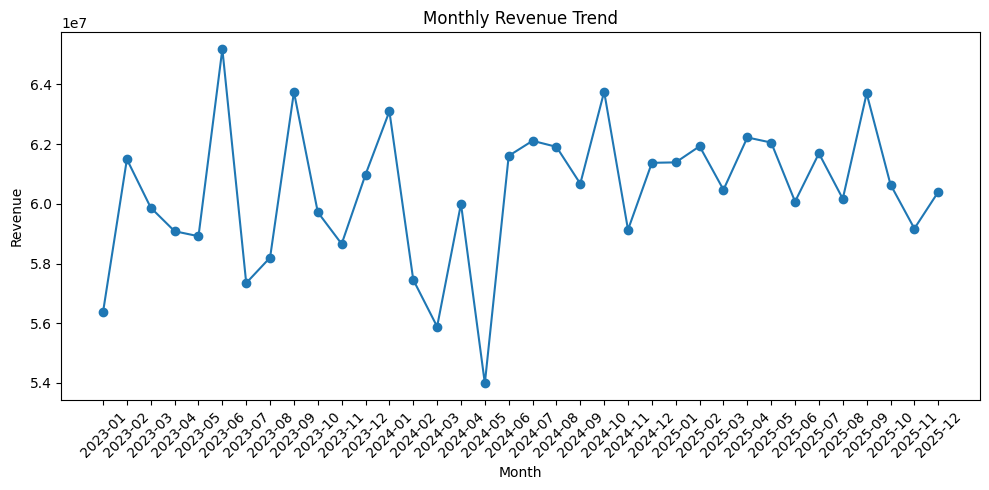

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_rev['order_month'].astype(str), monthly_rev['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [10]:
category_rev = (
    df.groupby('category', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

category_rev

,category,revenue
6,Premium Lifestyle,6.480969e+08
1,Electronics,5.205175e+08
7,Sports & Fitness,2.833666e+08
5,Home & Living,2.366783e+08
3,Footwear,1.957683e+08
2,Fashion,1.578753e+08
0,Beauty & Personal Care,1.016232e+08
4,Grocery Essentials,3.058428e+07


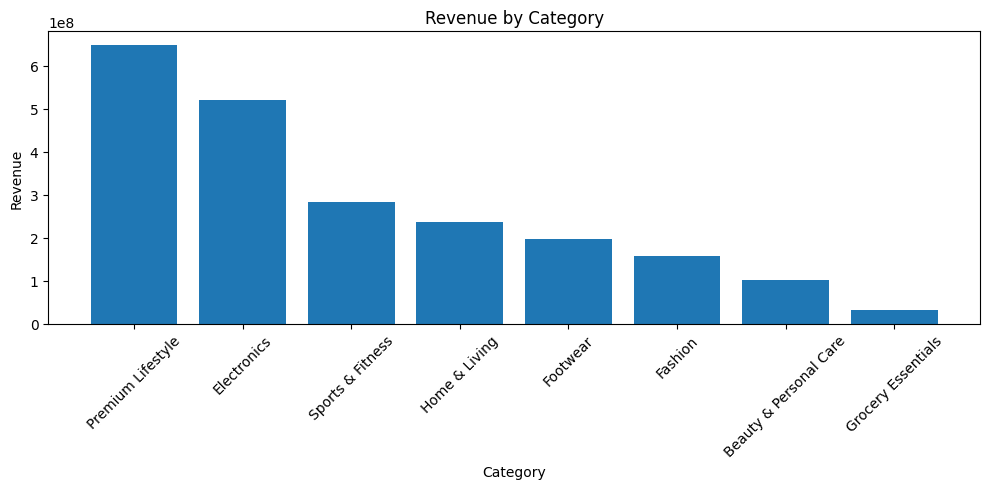

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(category_rev['category'], category_rev['revenue'])
plt.xticks(rotation=45)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [12]:
gender_rev = (
    df.groupby('customer_gender', as_index=False)['revenue']
      .sum()
)

gender_rev

### gender distribution

df['age_band'] = pd.cut(
    df['customer_age'],
    bins=[17, 25, 35, 45, 60, 80],
    labels=['18-25', '26-35', '36-45', '46-60', '60+']
)

age_rev = (
    df.groupby('age_band', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

age_rev

C:\Users\Anjali Singh\AppData\Local\Temp\ipykernel_35156\3757119371.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_band', as_index=False)['revenue']


,age_band,revenue
0,18-25,7.250588e+08
1,26-35,6.288005e+08
2,36-45,3.837094e+08
3,46-60,3.492276e+08
4,60+,8.771401e+07


In [14]:
discount_rev = (
    df.groupby('discount_band', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)
df['discount_band'] = pd.cut(
    df['discount_percent'],
    bins=[0, 10, 20, 30, 50, 100],
    labels=['0-10%', '10-20%', '20-30%', '30-50%', '50%+']
)

category_discount_rev = (
    df.groupby(['category', 'discount_band'], as_index=False)['revenue']
      .sum()
      .sort_values(['category', 'revenue'], ascending=[True, False])
)

category_discount_rev.head(20)

C:\Users\Anjali Singh\AppData\Local\Temp\ipykernel_35156\518265080.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('discount_band', as_index=False)['revenue']
C:\Users\Anjali Singh\AppData\Local\Temp\ipykernel_35156\518265080.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['category', 'discount_band'], as_index=False)['revenue']


,category,discount_band,revenue
3,Beauty & Personal Care,30-50%,4.145474e+07
4,Beauty & Personal Care,50%+,2.538626e+07
2,Beauty & Personal Care,20-30%,2.100937e+07
1,Beauty & Personal Care,10-20%,1.126518e+07
0,Beauty & Personal Care,0-10%,2.507653e+06
8,Electronics,30-50%,2.062380e+08
9,Electronics,50%+,1.353229e+08
7,Electronics,20-30%,1.019929e+08
6,Electronics,10-20%,6.211196e+07
5,Electronics,0-10%,1.485176e+07


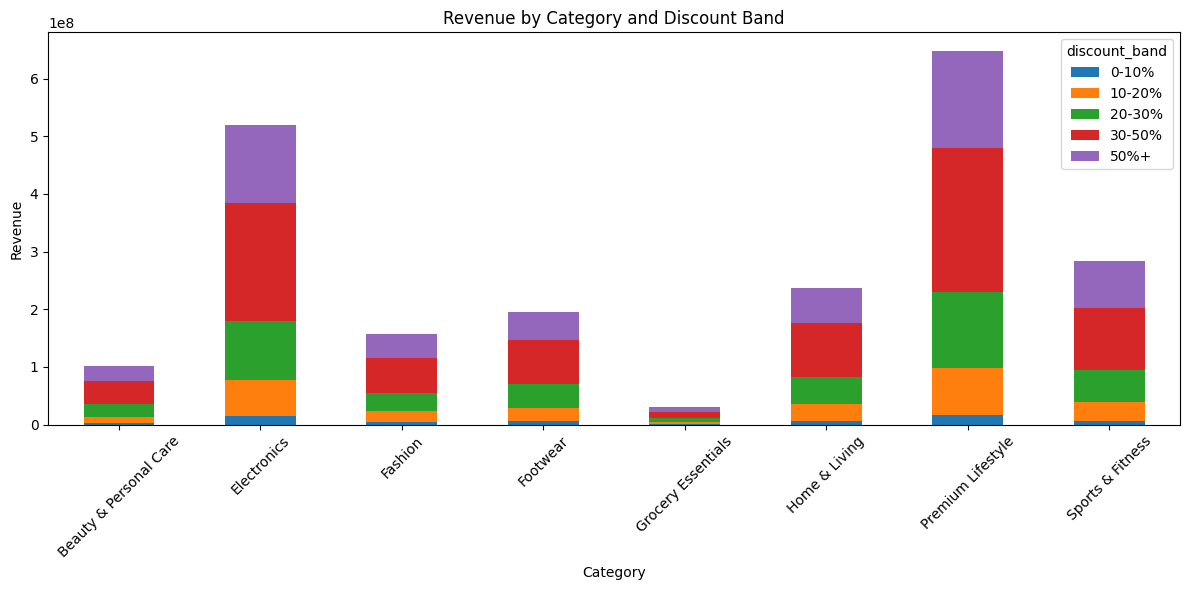

In [15]:
pivot_cd = category_discount_rev.pivot(
    index='category',
    columns='discount_band',
    values='revenue'
).fillna(0)

pivot_cd.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Revenue by Category and Discount Band")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
state_rev = (
    df.groupby('state', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

state_rev.head(10)
 

,state,revenue
1,Delhi NCR,1.956911e+08
7,Maharashtra,1.894436e+08
4,Karnataka,1.887672e+08
5,Kerala,1.683534e+08
2,Gujarat,1.682156e+08
11,Telangana,1.669118e+08
10,Tamil Nadu,1.654015e+08
9,Punjab,1.586658e+08
3,Haryana,1.572334e+08
6,Madhya Pradesh,1.312256e+08


In [18]:
zone_rev = (
    df.groupby('zone', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

zone_rev

,zone,revenue
3,South,6.894339e+08
2,North,6.365123e+08
4,West,3.576592e+08
0,Central,2.465746e+08
1,East,2.443304e+08


In [20]:
import os

output_base = r"C:\Users\Anjali Singh\Desktop\portpolio\data"
os.makedirs(output_base, exist_ok=True)

monthly_rev.to_csv(output_base + r"\monthly_revenue.csv", index=False)
category_rev.to_csv(output_base + r"\category_revenue.csv", index=False)
age_rev.to_csv(output_base + r"\age_revenue.csv", index=False)
zone_rev.to_csv(output_base + r"\zone_revenue.csv", index=False)
discount_rev.to_csv(output_base + r"\discount_revenue.csv", index=False)